In [ ]:
from google.colab import files
uploaded = files.upload()


Saving lithology_25k_ngdr.dbf to lithology_25k_ngdr.dbf
Saving lithology_25k_ngdr_20250224140917945.dbf to lithology_25k_ngdr_20250224140917945.dbf
Saving lithology_25k_ngdr.cpg to lithology_25k_ngdr.cpg
Saving lithology_25k_ngdr.prj to lithology_25k_ngdr.prj
Saving lithology_25k_ngdr.sbn to lithology_25k_ngdr.sbn
Saving lithology_25k_ngdr.sbx to lithology_25k_ngdr.sbx
Saving lithology_25k_ngdr.shp to lithology_25k_ngdr.shp
Saving lithology_25k_ngdr.shx to lithology_25k_ngdr.shx
Saving lithology_25k_ngdr_20250224140917945.prj to lithology_25k_ngdr_20250224140917945.prj
Saving lithology_25k_ngdr_20250224140917945.shp to lithology_25k_ngdr_20250224140917945.shp
Saving lithology_25k_ngdr_20250224140917945.shx to lithology_25k_ngdr_20250224140917945.shx


In [ ]:
import geopandas as gpd


gdf = gpd.read_file("lithology_25k_ngdr.shp")  # Don't include the other extensions


In [ ]:
gdf.columns

Index(['gid', 'input_cent', 'edition_no', 'toposheet_', 'geometry_i',
       'stratigrap', 'supergroup', 'group_name', 'sub_group', 'formation',
       'member', 'lithologic', 'standard_l', 'geochronol', 'g_age_erro',
       'g_age_syst', 'g_material', 'texture', 'major_mine', 'accessory_',
       'accession_', 'remarks', 'shape_leng', 'shape_area', 'geometry'],
      dtype='object')

In [ ]:
gdf.info()

<class 'geopandas.geodataframe.GeoDataFrame'>
RangeIndex: 3599 entries, 0 to 3598
Data columns (total 25 columns):
 #   Column      Non-Null Count  Dtype   
---  ------      --------------  -----   
 0   gid         3599 non-null   int32   
 1   input_cent  3599 non-null   object  
 2   edition_no  3599 non-null   int32   
 3   toposheet_  3599 non-null   object  
 4   geometry_i  0 non-null      object  
 5   stratigrap  3595 non-null   object  
 6   supergroup  2724 non-null   object  
 7   group_name  2895 non-null   object  
 8   sub_group   0 non-null      object  
 9   formation   2538 non-null   object  
 10  member      0 non-null      object  
 11  lithologic  3599 non-null   object  
 12  standard_l  3599 non-null   object  
 13  geochronol  0 non-null      object  
 14  g_age_erro  20 non-null     object  
 15  g_age_syst  20 non-null     object  
 16  g_material  0 non-null      object  
 17  texture     2530 non-null   object  
 18  major_mine  2818 non-null   object  
 19

In [ ]:
gdf.shape


(3599, 25)

In [ ]:
gdf.describe()

,gid,edition_no,shape_leng,shape_area
count,3599.000000,3599.0,3599.000000,3.599000e+03
mean,7464.596277,1.0,4384.125381,1.928914e+06
std,3138.048648,0.0,17284.389892,2.020317e+07
min,4494.000000,1.0,0.619438,6.627210e-03
25%,5395.500000,1.0,443.292477,5.197101e+03
50%,6296.000000,1.0,859.521920,1.508588e+04
75%,10974.500000,1.0,2295.711239,6.172792e+04
max,25424.000000,1.0,514538.514702,6.079972e+08


✅ Loaded shape file with columns: ['gid', 'input_cent', 'edition_no', 'toposheet_', 'geometry_i', 'stratigrap', 'supergroup', 'group_name', 'sub_group', 'formation', 'member', 'lithologic', 'standard_l', 'geochronol', 'g_age_erro', 'g_age_syst', 'g_material', 'texture', 'major_mine', 'accessory_', 'accession_', 'remarks', 'shape_leng', 'shape_area', 'geometry']
💾 Saved cleaned data to: cleaned_lithology_data.csv
📊 Final Data Shape: (3599, 13)


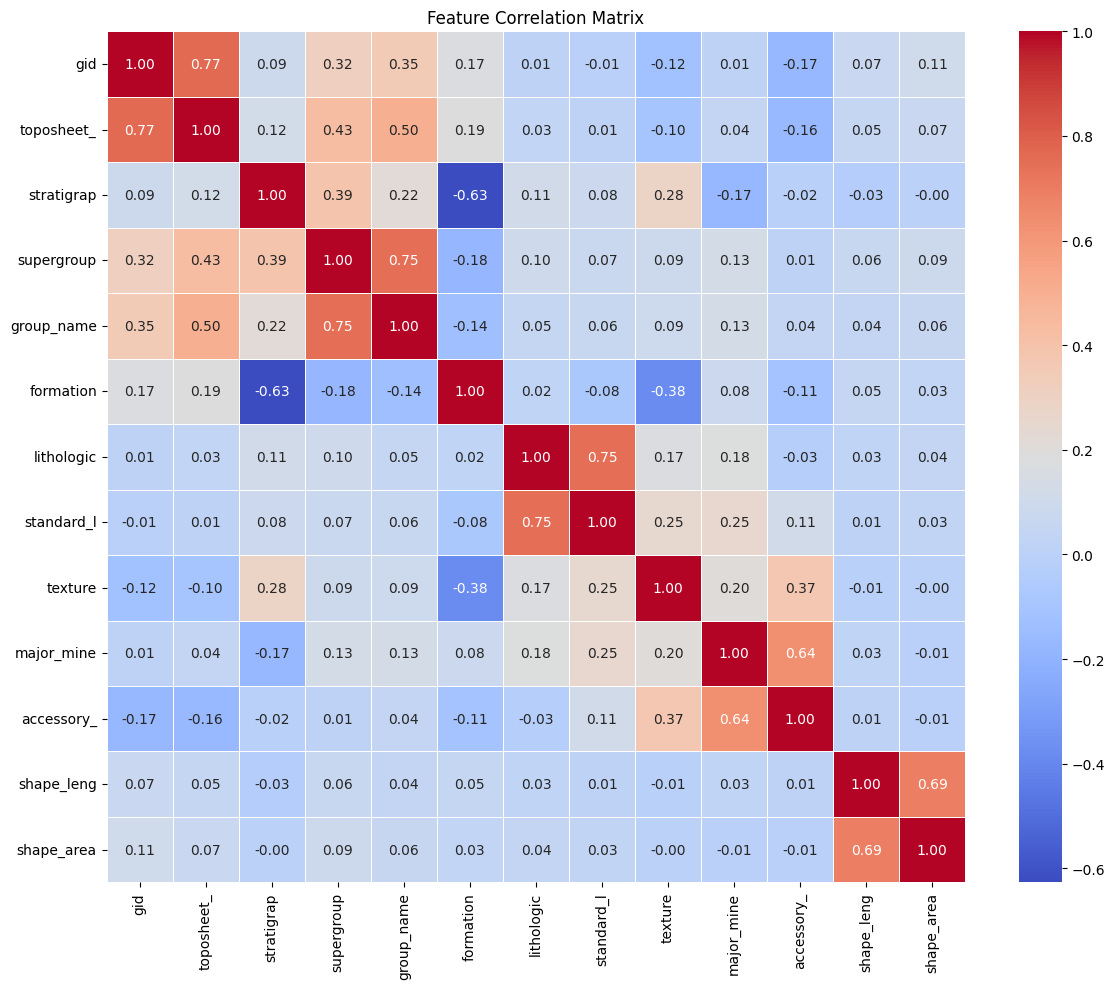


🔍 Correlation with Target Variable:
shape_area    1.000000
shape_leng    0.693481
gid           0.110273
supergroup    0.085631
toposheet_    0.065979
group_name    0.056514
lithologic    0.043934
formation     0.034561
standard_l    0.028305
texture      -0.002408
stratigrap   -0.003458
major_mine   -0.005614
accessory_   -0.006654
Name: shape_area, dtype: float64
📊 Random Forest RMSE: 9680026.3358 | R² Accuracy: 82.09%
📊 XGBoost RMSE: 7347181.5619 | R² Accuracy: 89.68%
📊 Gradient Boosting RMSE: 15355891.8239 | R² Accuracy: 54.93%

🏆 Best Model: XGBoost with Accuracy: 89.68%


In [ ]:
import geopandas as gpd
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from xgboost import XGBRegressor
from sklearn.metrics import mean_squared_error

# ---------------------------- Load Shapefile ----------------------------

shapefile_path = "lithology_25k_ngdr.shp"
gdf = gpd.read_file(shapefile_path)

print("✅ Loaded shape file with columns:", gdf.columns.tolist())

# ---------------------------- Standardize Columns ----------------------------

gdf.columns = gdf.columns.str.strip().str.lower().str.replace(" ", "_")

# ---------------------------- Data Cleaning ----------------------------

if "geometry" in gdf.columns:
    gdf.drop(columns=["geometry"], inplace=True)

columns_to_drop = []
for col in gdf.columns:
    if gdf[col].isnull().all():
        columns_to_drop.append(col)
    elif gdf[col].nunique() <= 1:
        columns_to_drop.append(col)
    elif gdf[col].isnull().mean() > 0.9:
        columns_to_drop.append(col)

irrelevant_cols = ["accession_", "remarks", "objectid", "fid", "uuid", "id"]
columns_to_drop += [col for col in irrelevant_cols if col in gdf.columns]

gdf.drop(columns=list(set(columns_to_drop)), inplace=True)

# Clean object columns and encode
for col in gdf.select_dtypes(include=["object"]).columns:
    gdf[col] = gdf[col].astype(str).str.strip().fillna("Unknown")
    le = LabelEncoder()
    gdf[col] = le.fit_transform(gdf[col])

# Fill missing numeric columns
for col in gdf.select_dtypes(include=[np.number]).columns:
    gdf[col] = gdf[col].fillna(gdf[col].mean())

# ---------------------------- Save Cleaned CSV ----------------------------

cleaned_csv_path = "cleaned_lithology_data.csv"
gdf.to_csv(cleaned_csv_path, index=False)
print(f"💾 Saved cleaned data to: {cleaned_csv_path}")
print("📊 Final Data Shape:", gdf.shape)

# ---------------------------- Correlation Analysis ----------------------------

plt.figure(figsize=(12, 10))
sns.heatmap(gdf.corr(), annot=True, cmap="coolwarm", fmt=".2f", linewidths=0.5)
plt.title("Feature Correlation Matrix")
plt.tight_layout()
plt.show()

# Show correlation with target
target_column = "edition_no" if "edition_no" in gdf.columns else gdf.columns[-1]
correlations = gdf.corr()[target_column].sort_values(ascending=False)
print("\n🔍 Correlation with Target Variable:")
print(correlations)

# ---------------------------- Normalize Numerical Data ----------------------------

X = gdf.drop(columns=[target_column])
y = gdf[target_column]

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
X = pd.DataFrame(X_scaled, columns=X.columns)

# ---------------------------- Split Dataset ----------------------------

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# ---------------------------- Model Training ----------------------------

rf = RandomForestRegressor(n_estimators=100, random_state=42)
xgb = XGBRegressor(n_estimators=100, learning_rate=0.1, max_depth=6, objective="reg:squarederror", random_state=42)
gb = GradientBoostingRegressor(n_estimators=100, learning_rate=0.1, max_depth=6, random_state=42)

rf.fit(X_train, y_train)
xgb.fit(X_train, y_train)
gb.fit(X_train, y_train)

# ---------------------------- Evaluation ----------------------------

from sklearn.metrics import r2_score

# ---------------------------- Evaluation ----------------------------

def evaluate(y_true, y_pred, model_name):
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    r2 = r2_score(y_true, y_pred)
    accuracy = r2 * 100
    print(f"📊 {model_name} RMSE: {rmse:.4f} | R² Accuracy: {accuracy:.2f}%")
    return accuracy

acc_rf = evaluate(y_test, rf.predict(X_test), "Random Forest")
acc_xgb = evaluate(y_test, xgb.predict(X_test), "XGBoost")
acc_gb = evaluate(y_test, gb.predict(X_test), "Gradient Boosting")

best_model = max([(acc_rf, "Random Forest"), (acc_xgb, "XGBoost"), (acc_gb, "Gradient Boosting")])
print(f"\n🏆 Best Model: {best_model[1]} with Accuracy: {best_model[0]:.2f}%")

